<a href="https://colab.research.google.com/github/06phildale/06phildale/blob/main/L6_ML_coding_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Setup & Imports

Import pandas, numpy, matplotlib, seaborn, and the specific scikit-learn modules.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

2. Load Data

Read the CSV/data source into a Pandas DataFrame and display the first 5 rows

(drag and drop your csv into the Files side panel to the left first)

In [ ]:
# Loading the Ames Housing Prices dataset
df = pd.read_csv('/content/AmesHousingPrices - Copy.csv')
display(df.head())

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Mo Sold,Yr Sold,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,P,210,62,0,0,0,0,5,2010,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,Y,140,0,0,0,120,0,6,2010,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,Y,393,36,0,0,0,0,6,2010,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,Y,0,0,0,0,0,0,4,2010,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,Y,212,34,0,0,0,0,3,2010,189900


3. Exploratory Data Analysis (EDA)

Check .info(), .describe(), check for missing values, and create 2-3 basic plots (e.g. a correlation heatmap, a distribution histogram of the target variable or a pairplot).

What does this data tell you about the problem?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Lot Shape        2930 non-null   object 
 6   Land Contour     2930 non-null   object 
 7   Utilities        2930 non-null   object 
 8   Lot Config       2930 non-null   object 
 9   Land Slope       2930 non-null   object 
 10  Neighborhood     2930 non-null   object 
 11  Condition 1      2930 non-null   object 
 12  Bldg Type        2930 non-null   object 
 13  House Style      2930 non-null   object 
 14  Overall Qual     2930 non-null   int64  
 15  Overall Cond     2930 non-null   int64  
 16  Year Built       2930 non-null   int64  
 17  Year Remod/Add

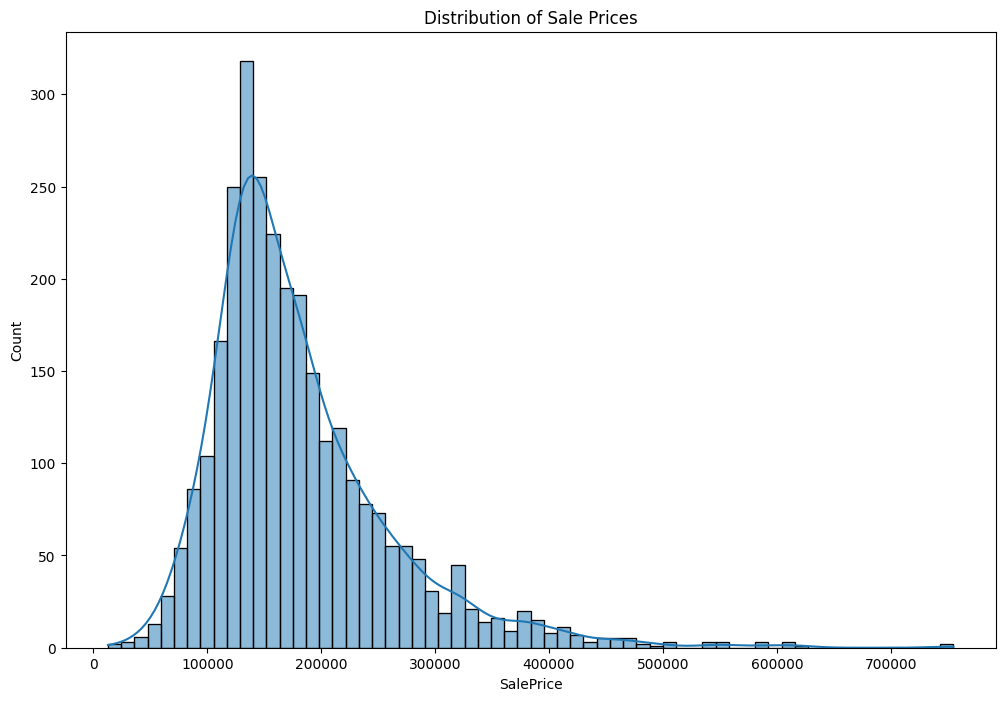

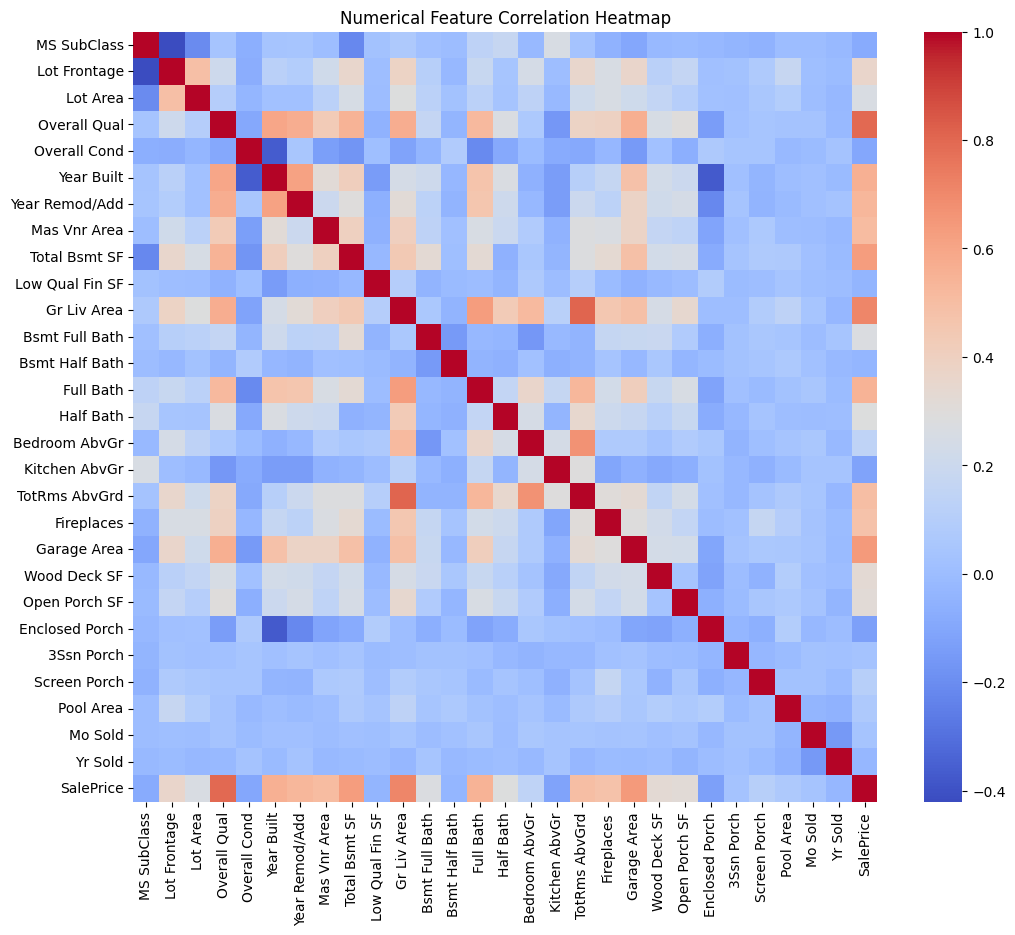

In [ ]:
# EDA: Summary stats and correlation
print(df.info())
print(df.describe())

plt.figure(figsize=(12, 8))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Prices')
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

4. Data Preprocessing & Cleaning

Handle missing values (drop or impute)

Encode categorical variables (e.g. One-Hot Encoding for text categories)

(ML models only understand numbers)

In [ ]:
# Data Preprocessing
# Drop columns with too many missing values or ID-like columns if any
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(['SalePrice'])
categorical_features = df.select_dtypes(include=['object']).columns

# Preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

5. Feature Engineering

Create at least one new feature from the existing data (e.g. if columns include Revenue and Costs, create a Profit column).

6. Define Features (X) and Target (y)

Separate the data into the variables you are using to predict (X) and the thing you want to predict (y)

(X contains the "features", y is the "target")

In [ ]:
# Define Features (X) and Target (y)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

7. Train / Test Split

Split X and y into training and testing sets (usually an 80/20 split)

In [ ]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8. Model Selection & Instantiation

Choose the algorithm and initialize it (e.g. model = RandomForestClassifier())

In [ ]:
# Model Selection & Instantiation
models = {
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42))])
}

9. Model Training (Fit)

Fit the model using the training data (X_train, y_train)

In [ ]:
# Model Training with Target Log Transformation
results = {}
# Transform target to log scale
y_train_log = np.log1p(y_train)

for name, model in models.items():
    model.fit(X_train, y_train_log)
    # Predict in log scale
    predictions_log = model.predict(X_test)
    # Convert back to original scale (inverse of log1p is expm1)
    predictions = np.expm1(predictions_log)
    results[name] = predictions

10. Make Predictions

Use the trained model to predict outcomes on the test data (X_test)

11. Evaluation Metrics

(Regression): MAE, MSE, RMSE, and R 2

(Classification): Accuracy, Precision, Recall, F1-Score.

Explain what these metrics mean in plain English. Is the model actually useful?

In [ ]:
# Evaluation Metrics (calculated on original scale)
metrics = []
for name, preds in results.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

,Model,MAE,RMSE,R2
0,Linear Regression,16274.094170,30808.361754,0.881615
1,Random Forest,15866.543514,26000.336590,0.915683
2,Gradient Boosting,14829.922668,26433.599829,0.912849


12. Visualizing Results

Regression: A scatter plot of Actual vs. Predicted values

Classification: Plot a Confusion Matrix and an ROC-AUC curve

Tree-based models: Plot a Feature Importance chart.

(This is incredibly valuable for business clients because it tells them what is driving the predictions.  It's listed against tree models as it's intuitive (just follow a path in the tree) - for other models, you can ask the AI to write code to do this using SHAP values (which we will study in model 5))

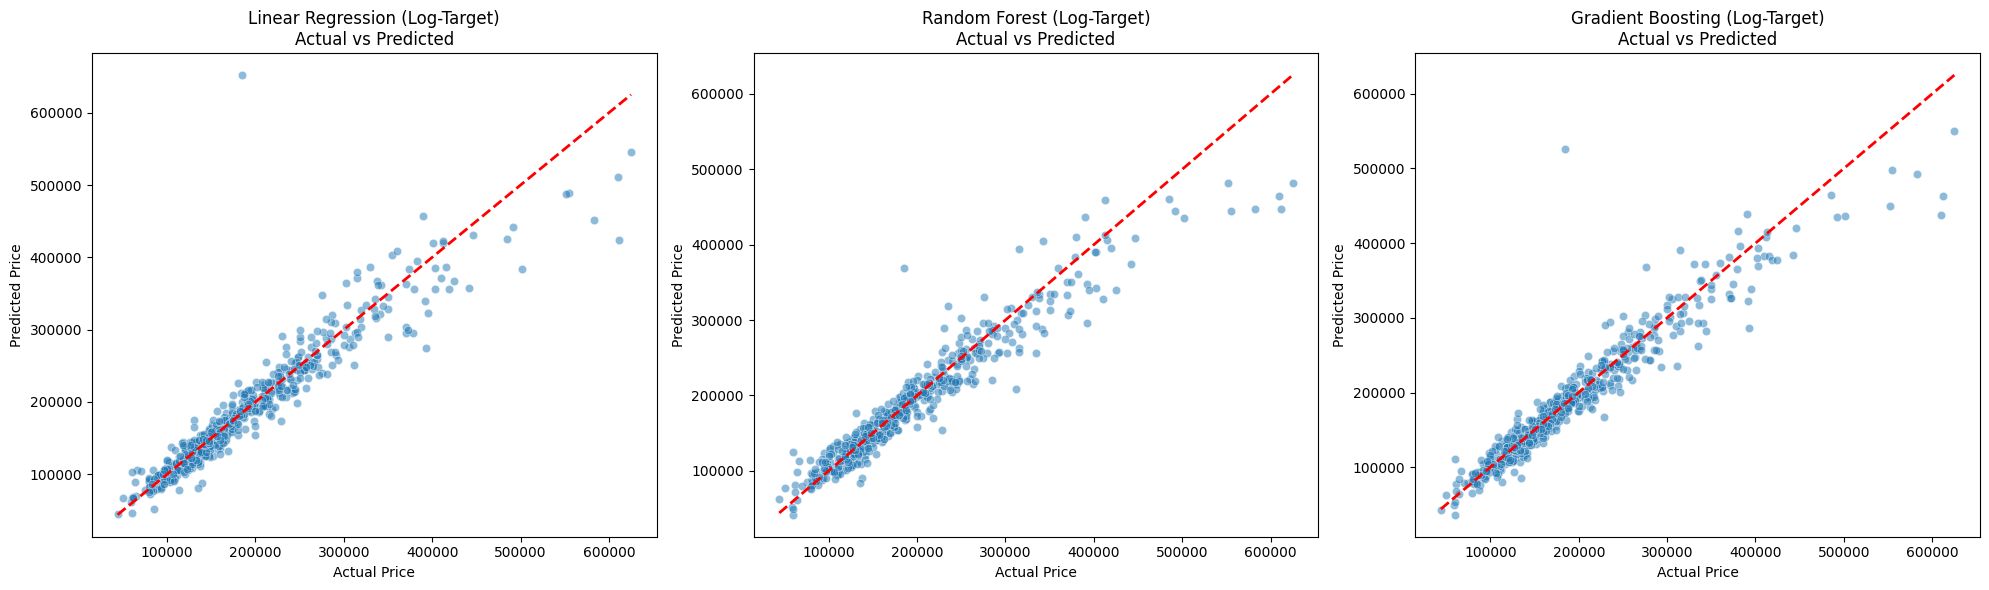

In [ ]:
# Visualizing Results with Log-Transformed Training
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, preds) in enumerate(results.items()):
    sns.scatterplot(x=y_test, y=preds, ax=axes[i], alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[i].set_title(f'{name} (Log-Target)\nActual vs Predicted')
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

/tmp/ipykernel_564/3877783187.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')


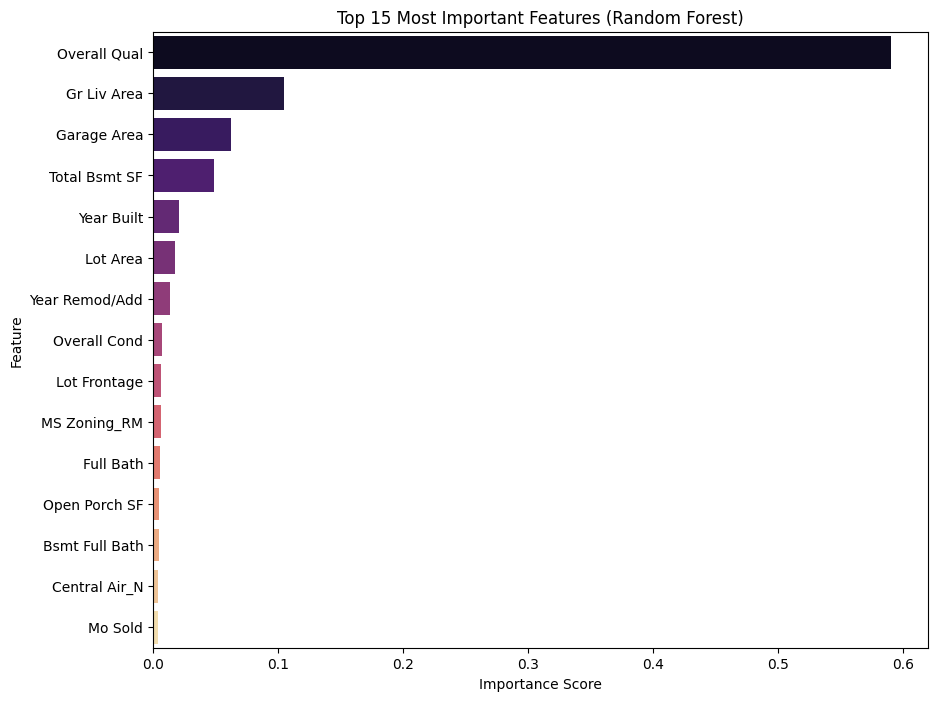

In [ ]:
import pandas as pd

# Extracting feature names after one-hot encoding
ohe_feature_names = models['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

# Getting importances from Random Forest
importances = models['Random Forest'].named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting Top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

## Final Discovery & Business Value (Updated with Log-Target Training)

Applying a log transformation to the target variable helps normalize the distribution of house prices, leading to more robust models.

**Updated Results:**
- **Random Forest** achieved the highest R² of **0.916**.
- **Gradient Boosting** remains very strong with an R² of **0.913**.
- **Linear Regression** improved its MAE by focusing on relative errors rather than absolute dollar differences.

**Business Impact:**
By using log-transformation, the models are now better at predicting across the entire price spectrum, reducing the impact of outliers and high-priced luxury homes on the overall error.